# Versuch 1 - Auswertung

Dieses Notebook dient dem systematischen herausschreiben der relevanten Codestellen des originalen Programms von Chiara Weckmann ```MSR_map_coil.ipynb```.
___
Erstellt am 29.Apr.2026 von Gregor Bock

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import scipy
from scipy.interpolate import griddata
import bfieldtools
from bfieldtools.utils import load_example_mesh,combine_meshes
import trimesh
import os
mu_0=scipy.constants.mu_0
pi=scipy.constants.pi

# Self made functions and classes
import Ausgelagerte_Funktionen_Versuchsauswertung as fkt
from Externe_Classes import Coil_Layup, Mu_material

c:\Users\grego\AppData\Local\Programs\Python\Python313\Lib\site-packages\bfieldtools\utils.py:21: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Load Experiment Data

This data was obtained on 27.Apr.2026. Therefore, coils were used on the left and right side of the MSR. They had a diameter of $d=0.34$ m, a horizontal distance of $d_x = 0.507$ m and a verticall distance of $d_z = 0.553$ m. The distances were measured with respect to the upper corners of the inner (wooden) room-side with the door.

In [2]:
# Specify folder path for .npz and points folder (.npz file should contain L_x, L_y, L_z, step_size, shift_x, shift_y, shift_z)
folder_path_points_no_current = r"D:\Studium\Physik\Bachelorarbeit\MSR-field_cancelation\after_degauss_no_current_2026-04-27_16-07-03\map\points"
folder_path_points_with_current = r"D:\Studium\Physik\Bachelorarbeit\MSR-field_cancelation\after_degauss_with_current_2026-04-27_16-54-25\map\points"

# If .npz file does not hold geometric track data, specify it here
L_x = 0.800                                         # length of the mapped volume in x-direction
L_y = 0.800                                         # length of the mapped volume in y-direction
L_z = 0.400                                         # length of the mapped volume in z-direction
step_size = 0.200                                   # size of the grid steps

shift_x = 0                                         # shift of the mapped volume in x-direction
shift_y = 0                                         # shift of the mapped volume in y-direction
shift_z = 0                                         # shift of the mapped volume in z-direction

# Load data using the function "load_data_from_folder" from the "Ausgelagerte_Funktionen_Versuchsauswertung.py" file.
target_point_coord, B_target_point_no_current, B_target_point_with_current = fkt.load_data_from_folder(folder_path_points_no_current, folder_path_points_with_current, L_x, L_y, L_z, step_size, shift_x, shift_y, shift_z)

Target point coordinates and B-field at target points both need to have dimension (n_points, 3).
  Shape of target coordinates: (75, 3)
  Shape of B-field with current at target points: (75, 3)
  Shape of B-field without current at target points: (75, 3)


## Plot the extracted Data

Plot each $B$-field component as well as the norm of the $B$-field of both maps (with and without coil current) directly next to each other for better comparison.

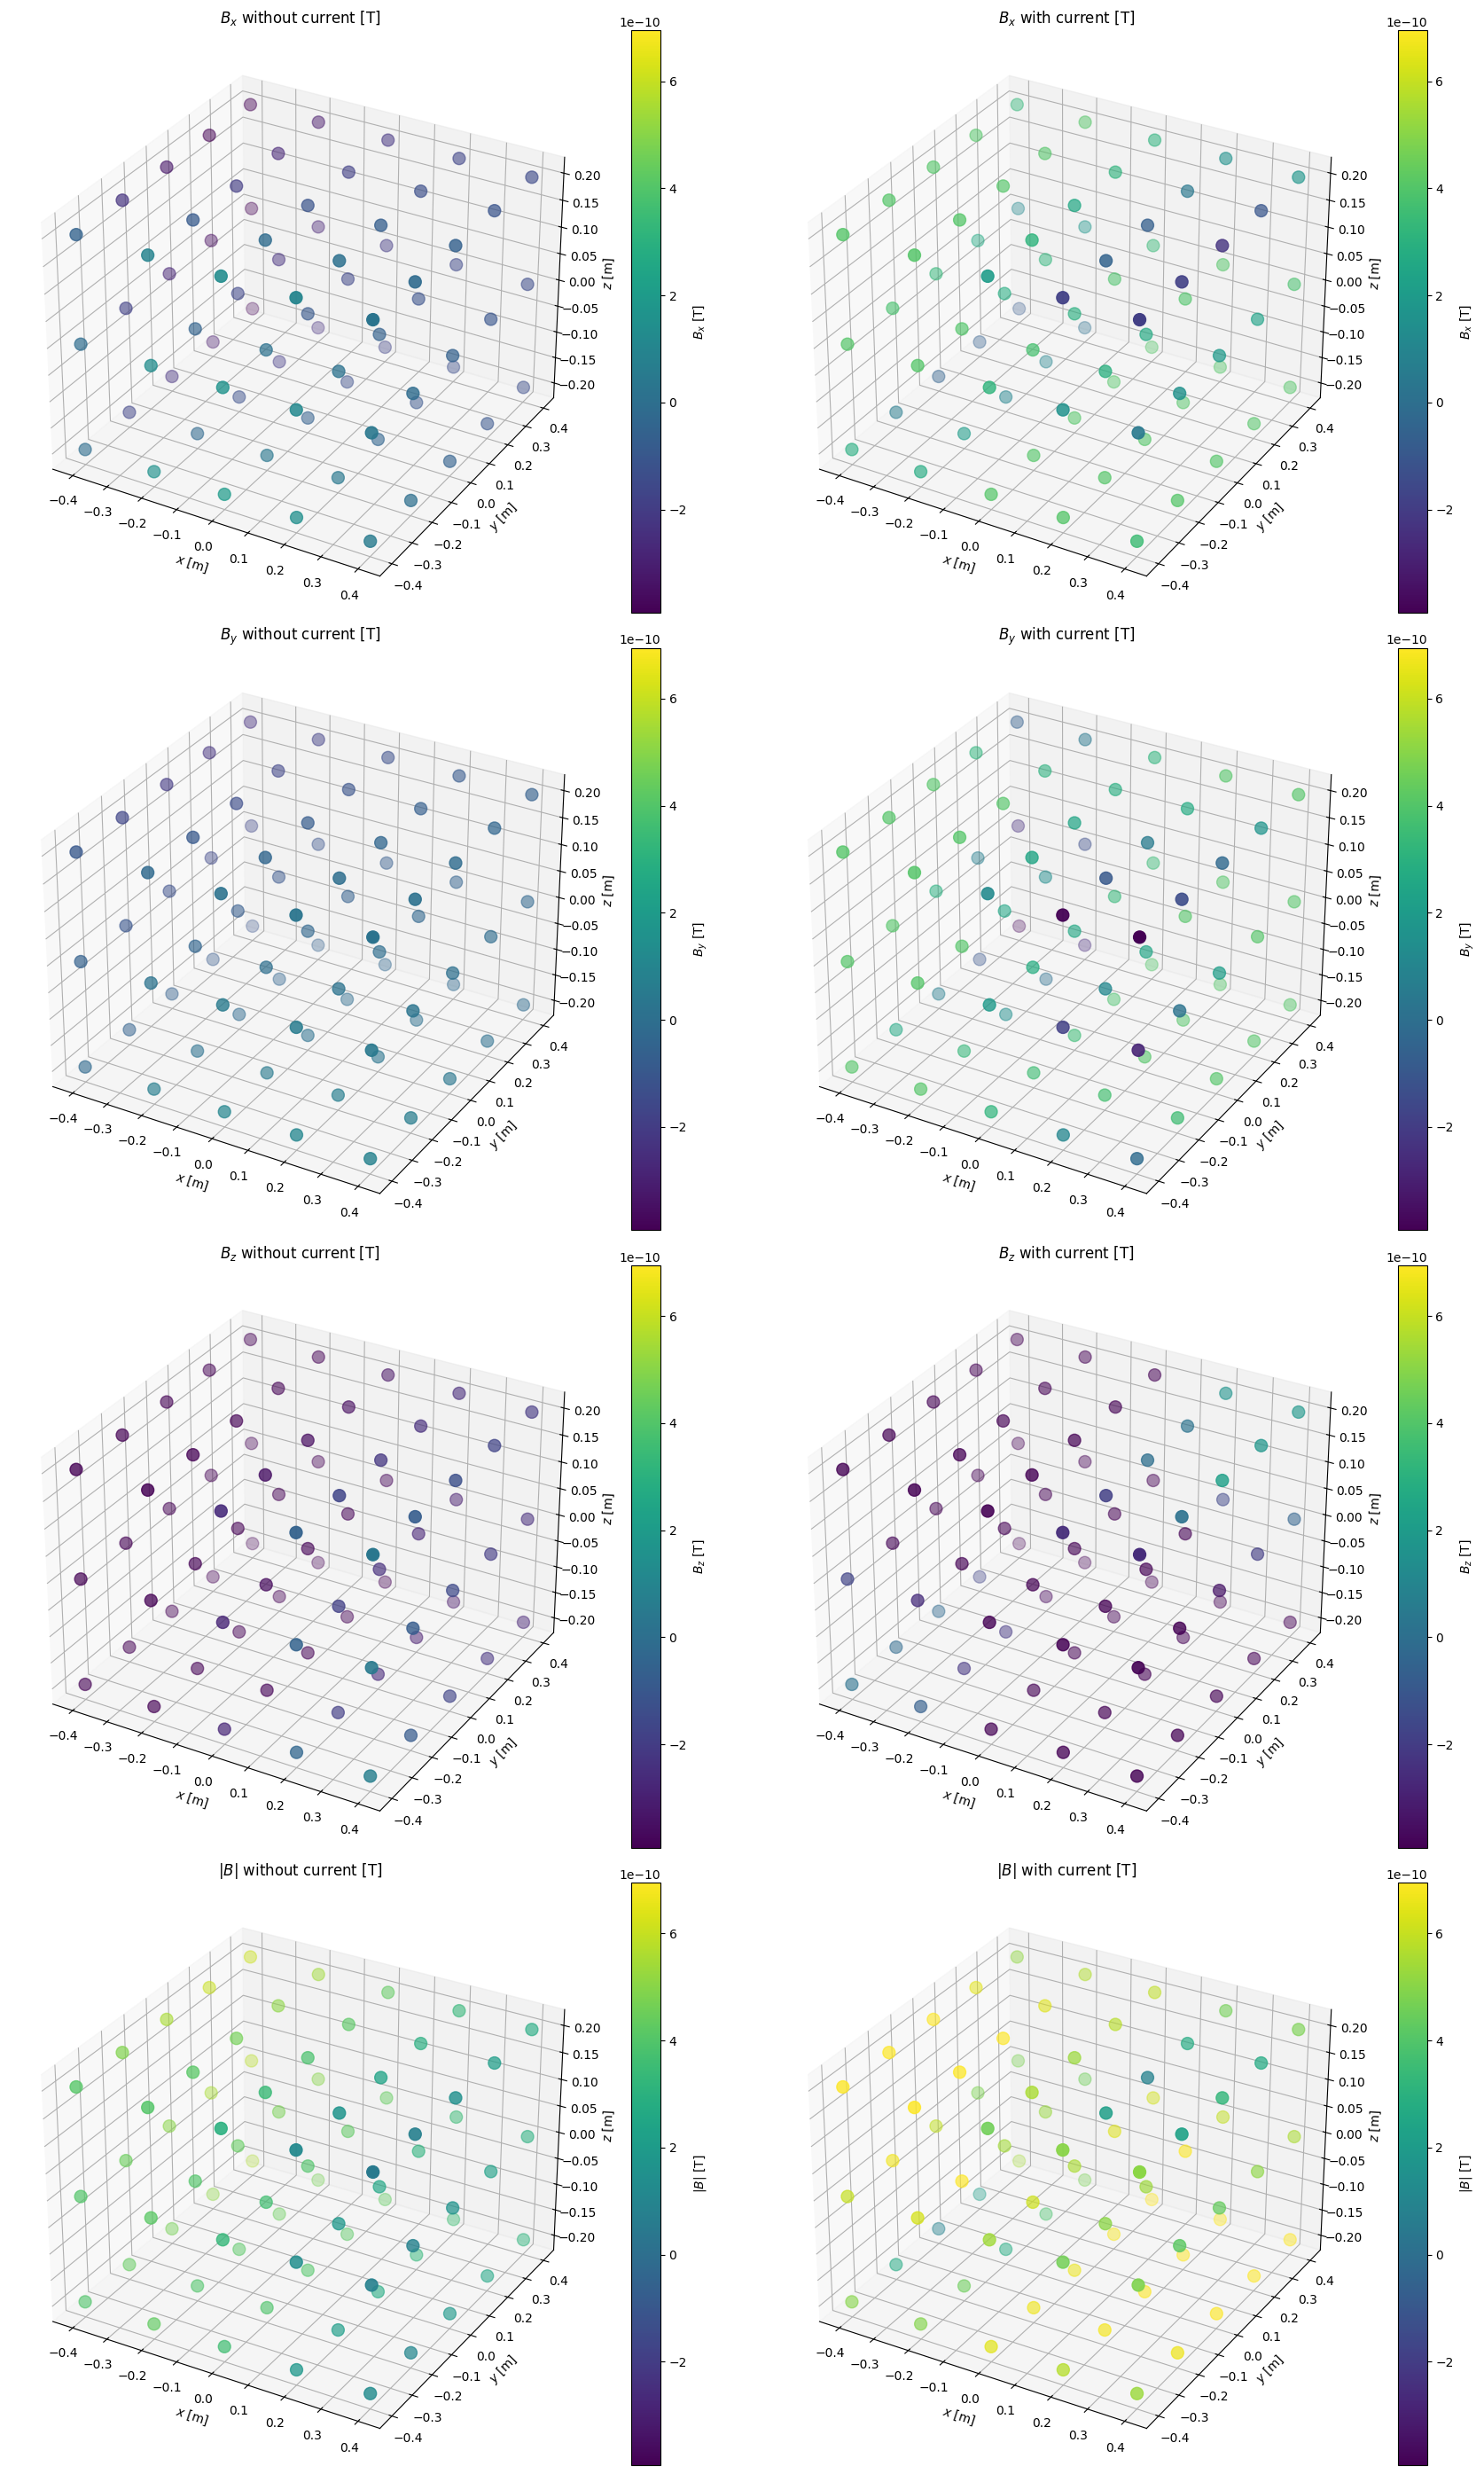

In [3]:
x = target_point_coord[:, 0]
y = target_point_coord[:, 1]
z = target_point_coord[:, 2]

Bx_no_I = B_target_point_no_current[:, 0]
By_no_I = B_target_point_no_current[:, 1]
Bz_no_I = B_target_point_no_current[:, 2]
Bnorm_no_I = np.linalg.norm(B_target_point_no_current, axis=1)

Bx_with_I = B_target_point_with_current[:, 0]
By_with_I = B_target_point_with_current[:, 1]
Bz_with_I = B_target_point_with_current[:, 2]
Bnorm_with_I = np.linalg.norm(B_target_point_with_current, axis=1)

fig = plt.figure(figsize=(18, 28))
axs = [
    fig.add_subplot(4, 2, 1, projection='3d'),
    fig.add_subplot(4, 2, 3, projection='3d'),
    fig.add_subplot(4, 2, 5, projection='3d'),
    fig.add_subplot(4, 2, 7, projection='3d'),
    fig.add_subplot(4, 2, 2, projection='3d'),
    fig.add_subplot(4, 2, 4, projection='3d'),
    fig.add_subplot(4, 2, 6, projection='3d'),
    fig.add_subplot(4, 2, 8, projection='3d')
]

component_data = [Bx_no_I, By_no_I, Bz_no_I, Bnorm_no_I, Bx_with_I, By_with_I, Bz_with_I, Bnorm_with_I]
v_min = min(d.min() for d in component_data)
v_max = max(d.max() for d in component_data)
titles = [
    r'$B_x$ without current [T]',
    r'$B_y$ without current [T]',
    r'$B_z$ without current [T]',
    r'$|B|$ without current [T]',
    r'$B_x$ with current [T]',
    r'$B_y$ with current [T]',
    r'$B_z$ with current [T]',
    r'$|B|$ with current [T]'
]
plots = [
    (Bx_no_I, r'$B_x$ [T]', v_min, v_max),
    (By_no_I, r'$B_y$ [T]', v_min, v_max),
    (Bz_no_I, r'$B_z$ [T]', v_min, v_max),
    (Bnorm_no_I, r'$|B|$ [T]', v_min, v_max),
    (Bx_with_I, r'$B_x$ [T]', v_min, v_max),
    (By_with_I, r'$B_y$ [T]', v_min, v_max),
    (Bz_with_I, r'$B_z$ [T]', v_min, v_max),
    (Bnorm_with_I,r'$|B|$ [T]', v_min, v_max)
]
for ax, (data, label, vmin, vmax), title in zip(axs, plots, titles):
    sc = ax.scatter(x, y, z, c=data, s=100, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel(r'$x$ [m]')
    ax.set_ylabel(r'$y$ [m]')
    ax.set_zlabel(r'$z$ [m]')
    plt.colorbar(sc, ax=ax, label=label)

# fig.suptitle(f'First Measurement of coil influence on B-field at target points', fontsize = 20)
plt.tight_layout()
plt.show()

## Geometric Data of MSR

All geometric data of the MSR as well the coil Layup is given in meters and ampere (generally only SI-base units)!

In [4]:
# Inner shield
shield_dim = 2.3            # length, width and height of the inner most shield
shield_thickness = 1e-3     # thickness of the shield walls

# Door
door_width = 0.95           # (width of the door)
door_height = 2.004         # (height of the door)
door_offset_x = 0.2375      # (distance from door frame to right wall)
door_floor_offset = 0.0     # (distance from door frame to floor)

# Inner wood structure
height_inner_wood = 2.20    # height of the inner wooden structure
width_inner_wood = 2.34     # width of the inner wooden structure
depth_inner_wood = 2.34     # depth of the inner wooden structure

# Coil Layout
coil_diameter = 0.34                # diameter of the coils
z_dist = 0.506                      # vertical distance between coils
x_dist = 0.553                      # horizontal distance between coils (x-direction)
y_dist = 0.553                      # horizontal distance between coils (y-direction)
coil_plane_dist_to_origin_x = 1.5   # distance from the center of the room to the plane where the coils are placed in x-direction
coil_plane_dist_to_origin_y = 1.5   # distance from the center of the room to the plane where the coils are placed in y-direction
coil_plane_dist_to_origin_z = 1.5   # distance from the center of the room to the plane where the coils are placed in z-direction
usable_length_x = 2.34              # usable length in x-direction for coil placement
usable_length_y = 2.34              # usable length in y-direction for coil placement
usable_length_z = 2.20              # usable length in z-direction for coil placement
n_windings = 10                     # number of windings per coil
current = 1.0                       # current in A flowing through the coils
# Note: One can give a scalar input for n_windings, which will be applied to every coil
#       or a list of integer numbers, which need to has the same length as coils present in the layout (if the shapes do not match, an error accours!)


## Call instance to Coil_Layup class

The class '''Coil_Layup''' from the file **Externe_Classes.py** is called to give the coil geometries by inputting all the geometric data.

Furthermore, this block plots the coils which were specified by the geomertic data as well as the centers of these coils.

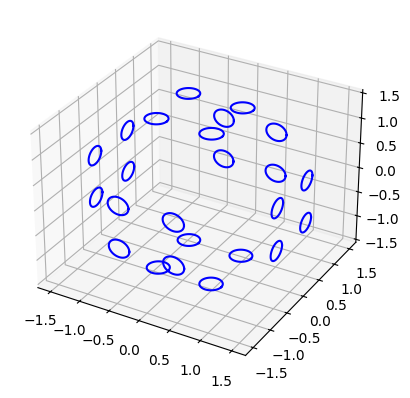

(24, 100, 3)


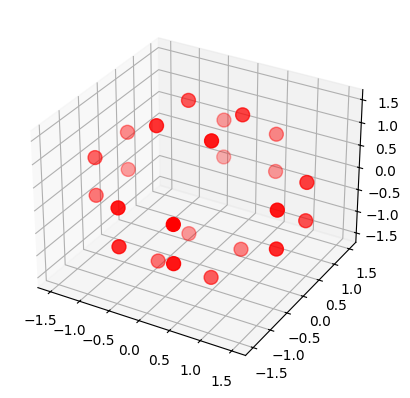

In [5]:
Coils = Coil_Layup(coil_diameter, x_dist, y_dist, z_dist, n_windings, current, coil_plane_dist_to_origin_x, coil_plane_dist_to_origin_y, coil_plane_dist_to_origin_z, usable_length_x, usable_length_y, usable_length_z)
all_circles = Coils.all_coils  # Shape: (n_coils_xy, 100, 3)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for k in range(all_circles.shape[0]):
    ax.plot(all_circles[k, :, 0], all_circles[k, :, 1], all_circles[k, :, 2], color='blue')
plt.show()

fig_grid = plt.figure()
ax_grid = fig_grid.add_subplot(111, projection='3d')
ax_grid.scatter(Coils.grid[:, 0], Coils.grid[:, 1], Coils.grid[:, 2], color='red', s=100)

print(all_circles.shape)


## Predicted $B$-field - only coils, no $\mu$-metal

By calling the method ```coil_field_by_Biot_Savart``` one can calculate the $B$-field which is produced by the coil layup without the influence of the $\mu$-metal and without consideration of the residual field.

This block also plots the result.

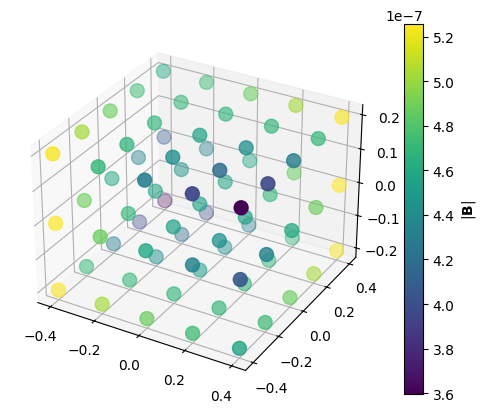

In [6]:
B_predict = Coils.coil_field_by_Biot_Savart(target_point_coord)

Bmag = np.linalg.norm(B_predict, axis=1)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(
    target_point_coord[:, 0],
    target_point_coord[:, 1],
    target_point_coord[:, 2],
    c=Bmag,
    s=100,
    cmap='viridis'
)
fig.colorbar(sc, ax=ax, label=r'$|\mathbf{B}|$')

## Shield meshing class

To account for the $mu$-metal a meshed geometry accourding to the specified geometric data can be created by calling the class ```Mu_material``` from the file **Externe_Classes.py**. This will output a triangular mesh of the $mu$-metal surface.

This block also plots the mesh (of one planar surface), the mesh boundaries (should be an empty plot) as well as the cells in 3D just as in the original programm.

In [7]:
mu_grid = Mu_material(shield_dim, shield_thickness)

# # From here on, plotting starts!!!
# # plot triangular grid of one planar surface
# fig, ax = plt.subplots(figsize=(6,6))
# ax.triplot(mu_grid.triang_shield, color='k', linewidth=0.8)

# # plot meshboundaries of the mu-metal
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# inner_idx_shield=bfieldtools.utils.find_mesh_boundaries(mu_grid.total_shield)
# inner_vertex_idx_shield=inner_idx_shield[0]
# for idx in inner_vertex_idx_shield:
#     boundary=mu_grid.total_shield.vertices[idx]
#     ax.scatter(boundary[:,0],boundary[:,1],boundary[:,2])

# # plot vertices
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# verts_shield = mu_grid.total_shield.vertices
# ax.scatter(verts_shield[:,0],verts_shield[:,1],verts_shield[:,2],alpha=0.5)

# # plot vertices of the shield and points inside the shield
# points_inside = mu_grid.total_shield.vertices - mu_grid.shield_thickness * mu_grid.total_shield.vertex_normals
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# ax.scatter(verts_shield[:,0],verts_shield[:,1],verts_shield[:,2],alpha=0.3)
# ax.scatter(points_inside[:,0],points_inside[:,1],points_inside[:,2],alpha=0.3)

## $\mu$-metal influence

## First try using bfieldtools

- Calculate coupling matrix $C$

\begin{equation}
    B(r_j) = \sum_i C_{ji}s_i
\end{equation}
where $s_i$ is the stream function at node $i$ of the mesh. This matrix can be derived purely by the geometrical data of the problem.

- Assume that the stream function of the shield tries to balance out the B-field of the magnetic coils. For a perfect MSR, this would mean, that ```B_shield = -B_coils```. The ```reshape(-1)``` is necessary to flatten the B-array (convert it to an array of 1D).

- Solve the least square problem
\begin{equation}
    ||C_{Coupling} \cdot stream_func - b_target||_2^2
\end{equation}
which gives the stream function, such that the created B-field matches the coil field as much as possible.

- ```bfieldtools.mesh_conductor.StreamFunction``` brings the stream-function into a container form after coefficients were already calculated.

- After this, we can calculate the $B$-field by performing the matrix-vector-product.
\begin{equation}
    B_{shield} = B_{coupling} \cdot stream_func_opt
\end{equation}

- Bring B-field in useable shape

- Plot total field

In [11]:
# Build the magnetic-field coupling matrix from the shield mesh to the target points.
# Expected shapes:
#   mu_grid.total_shield: a trimesh object with vertices and faces
#   target_point_coord: (n_targets, 3)
#   C_coupling: typically a 2D array with shape (3 * n_targets, n_stream_coeffs)
C_coupling = bfieldtools.mesh_magnetics.magnetic_field_coupling(
    mu_grid.total_shield,
    target_point_coord
)

# Reshape the coupling matrix to a strict 2D matrix if the library returns it with extra axes.
# Expected shape after reshaping:
#   C_coupling_2d: (3 * n_targets, n_stream_coeffs)
C_coupling_2d = np.asarray(C_coupling).reshape(-1, np.asarray(C_coupling).shape[-1])

# Flatten the desired target field into a 1D vector.
# Expected shapes:
#   B_predict: (n_targets, 3)
#   b_target: (3 * n_targets,)
# What happens: the coil field is converted into the same vector form as the coupling matrix output.
b_target = (-B_predict).reshape(-1)

# Solve the least-squares problem for the stream-function coefficients.
# Expected shapes:
#   C_coupling_2d: (3 * n_targets, n_stream_coeffs)
#   b_target: (3 * n_targets,)
#   stream_func_opt: (n_stream_coeffs,)
# What happens: finds the stream-function coefficients whose shield field best cancels the coil field in the least-squares sense.
stream_func_opt, *_ = np.linalg.lstsq(C_coupling_2d, b_target, rcond=None)

# Wrap the solved coefficients in a bfieldtools StreamFunction object.
# Expected shapes:
#   stream_func_opt: (n_stream_coeffs,)
#   mu_grid.shield_conductor: MeshConductor object
# What happens: stores the solved stream function on the shield mesh basis for later inspection or plotting.
stream_func = bfieldtools.mesh_conductor.StreamFunction(
    stream_func_opt,
    mu_grid.shield_conductor
)

# Evaluate the shield field from the solved stream function.
# Expected shapes:
#   B_shield_flat: (3 * n_targets,)
#   B_shield: (n_targets, 3)
# What happens: applies the coupling matrix to the optimized stream function and reshapes the result back into vector form per target point.
B_shield = (C_coupling_2d @ stream_func_opt).reshape(-1, 3)

# Add coil field and shield field to obtain the total field.
# Expected shapes:
#   B_predict: (n_targets, 3)
#   B_shield: (n_targets, 3)
#   B_total: (n_targets, 3)
# What happens: combines the known coil field with the induced shield field.
B_total = B_predict + B_shield

Computing magnetic field coupling matrix, 7778 vertices by 75 target points... took 0.36 seconds.
